In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan=pd.read_csv("loan_approval_data.csv")

In [3]:
# loan.head()
# loan.info()
# loan.isnull().sum()
loan.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handling Missing Values


In [4]:
caterogical_cols=loan.select_dtypes(include=["object"]).columns
numerical_cols=loan.select_dtypes(include=["number"]).columns
print(caterogical_cols)
print(numerical_cols)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [5]:
from sklearn.impute import SimpleImputer

#Handling Numerical missing values
num_imp=SimpleImputer(strategy="mean");
loan[numerical_cols]=num_imp.fit_transform(loan[numerical_cols])

In [6]:
loan[numerical_cols].isnull().sum() #verify
loan[numerical_cols].head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0


In [7]:
#Handling Categorical missing values
cat_imp=SimpleImputer(strategy="most_frequent");
loan[caterogical_cols]=cat_imp.fit_transform(loan[caterogical_cols])

In [8]:
loan[caterogical_cols].isnull().sum() #verify
loan[caterogical_cols].head()

,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes


In [9]:
#Overall Verification
loan.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA (Exploratory Data Analysis)

In [10]:
#How balanced our classes are?

classes_count=loan["Loan_Approved"].value_counts()
classes_count

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

Text(0.5, 1.0, 'Is The Loan Approved or not?')

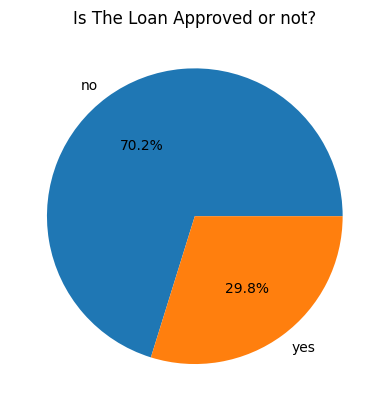

In [11]:
plt.pie(classes_count,labels=["no","yes"],autopct="%1.1f%%")  #skewed classes/ data as it is real life data
plt.title("Is The Loan Approved or not?")

In [12]:
#Analyze Categories

#Gender
gender_count=loan["Gender"].value_counts()
gender_count

Gender
Male      621
Female    379
Name: count, dtype: int64

[Text(0, 0, '621'), Text(0, 0, '379')]

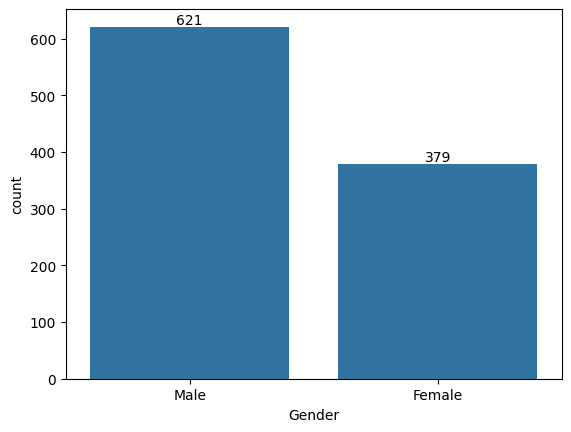

In [13]:
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

In [14]:
#Education
edu_count=loan["Education_Level"].value_counts()
edu_count

Education_Level
Graduate        722
Not Graduate    278
Name: count, dtype: int64

[Text(0, 0, '722'), Text(0, 0, '278')]

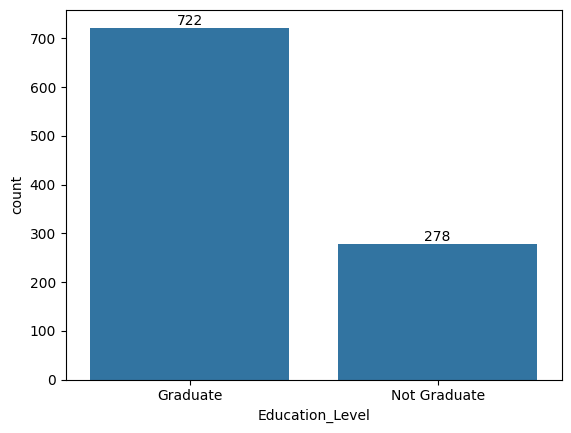

In [15]:
ax=sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

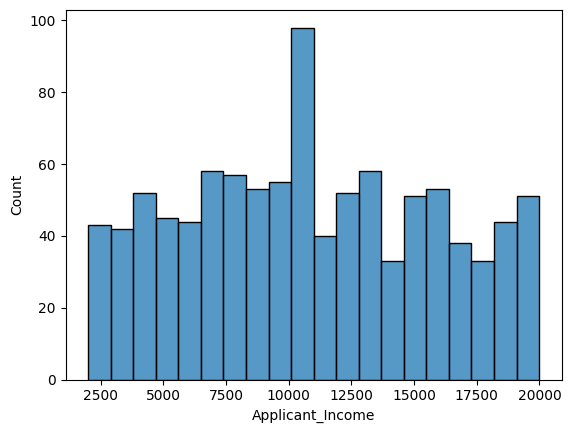

In [16]:
#Analyze the income

sns.histplot(
    data=loan,
    x="Applicant_Income",
    bins=20
    
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

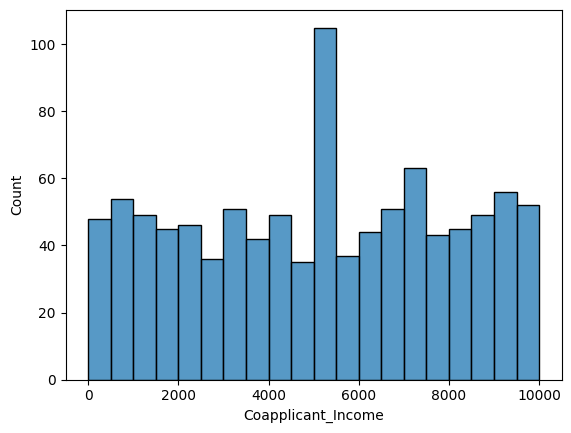

In [17]:
sns.histplot(
    data=loan,
    x="Coapplicant_Income",
    bins=20
    
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

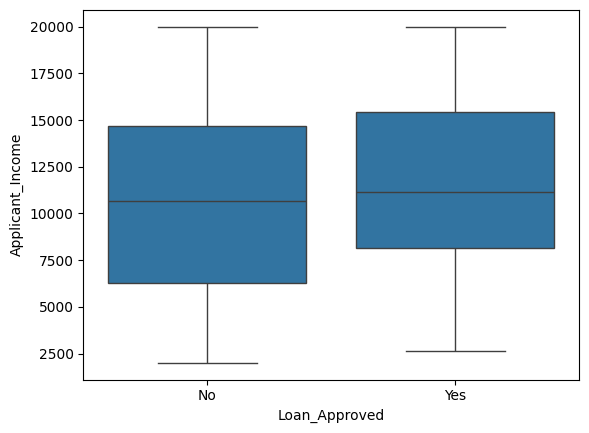

In [18]:
#Inorder to detect outliers we use boxplots

sns.boxplot(
    data=loan,
    x="Loan_Approved",
    y="Applicant_Income"
    
)

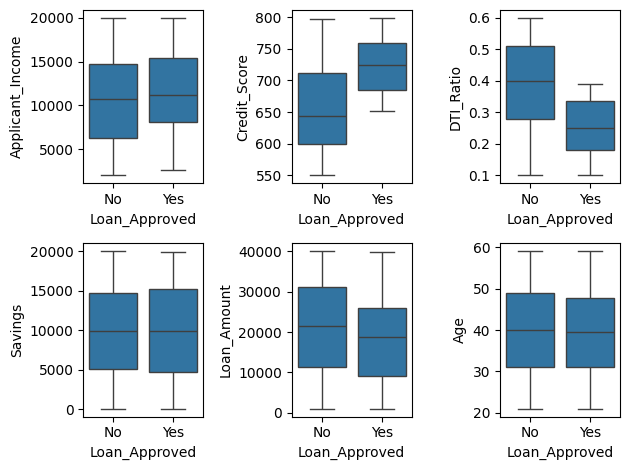

In [19]:
#Detecting more outlier using boxplots
fig,axes=plt.subplots(2,3)

sns.boxplot(ax=axes[0,0],data=loan,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=loan,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,2],data=loan,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data=loan,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1],data=loan,x="Loan_Approved",y="Loan_Amount")
sns.boxplot(ax=axes[1,2],data=loan,x="Loan_Approved",y="Age")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

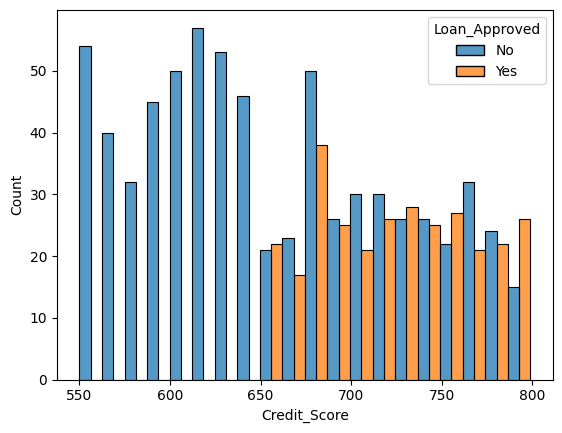

In [20]:
#Credit Score with Loan Approved

sns.histplot(
    data=loan,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)#Very meaningful insights can be drawn i.e loan is approved for customers having Credit Scores more than 650

<Axes: xlabel='Applicant_Income', ylabel='Count'>

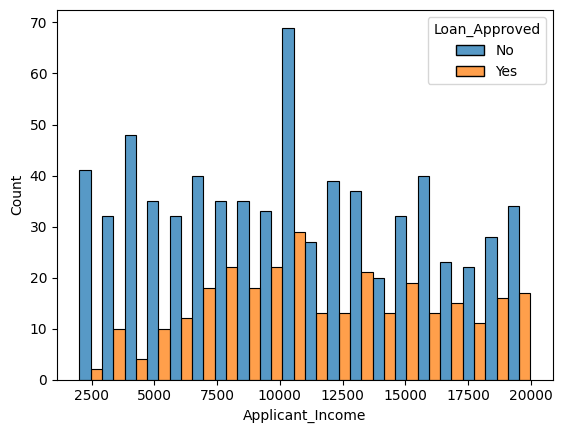

In [21]:
#Applicant_Income with Loan Approved

sns.histplot(
    data=loan,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
) #No meaningful insights can be drawn as loan is approved for any range of incomes , same is with the Coapplicant_Income

In [22]:
loan=loan.drop("Applicant_ID",axis=1)

In [23]:
loan.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [24]:
loan.head()
loan.columns
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [25]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#LabelEncoding for Ordinal Data
le=LabelEncoder()
loan["Education_Level"]=le.fit_transform(loan["Education_Level"])
loan["Loan_Approved"]=le.fit_transform(loan["Loan_Approved"])


In [26]:
loan.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [27]:
#OneHotEncoding for Nominal data

ohe=OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore")

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

encoded=ohe.fit_transform(loan[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=loan.index)

loan=pd.concat([loan.drop(columns=cols),encoded_df],axis=1)

In [28]:
loan.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [29]:
loan.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

In [30]:
loan.describe()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,...,0.181000,0.190000,0.178000,0.189000,0.517000,0.621000,0.202000,0.144000,0.422000,0.097000
std,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,...,0.385211,0.392497,0.382704,0.391705,0.499961,0.485381,0.401693,0.351265,0.494126,0.296106
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [32]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [33]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [34]:
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

# Correlation Heatmap

In [35]:
num_cols=loan.select_dtypes(include="number")
corr_matrix=num_cols.corr()
# corr_matrix
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

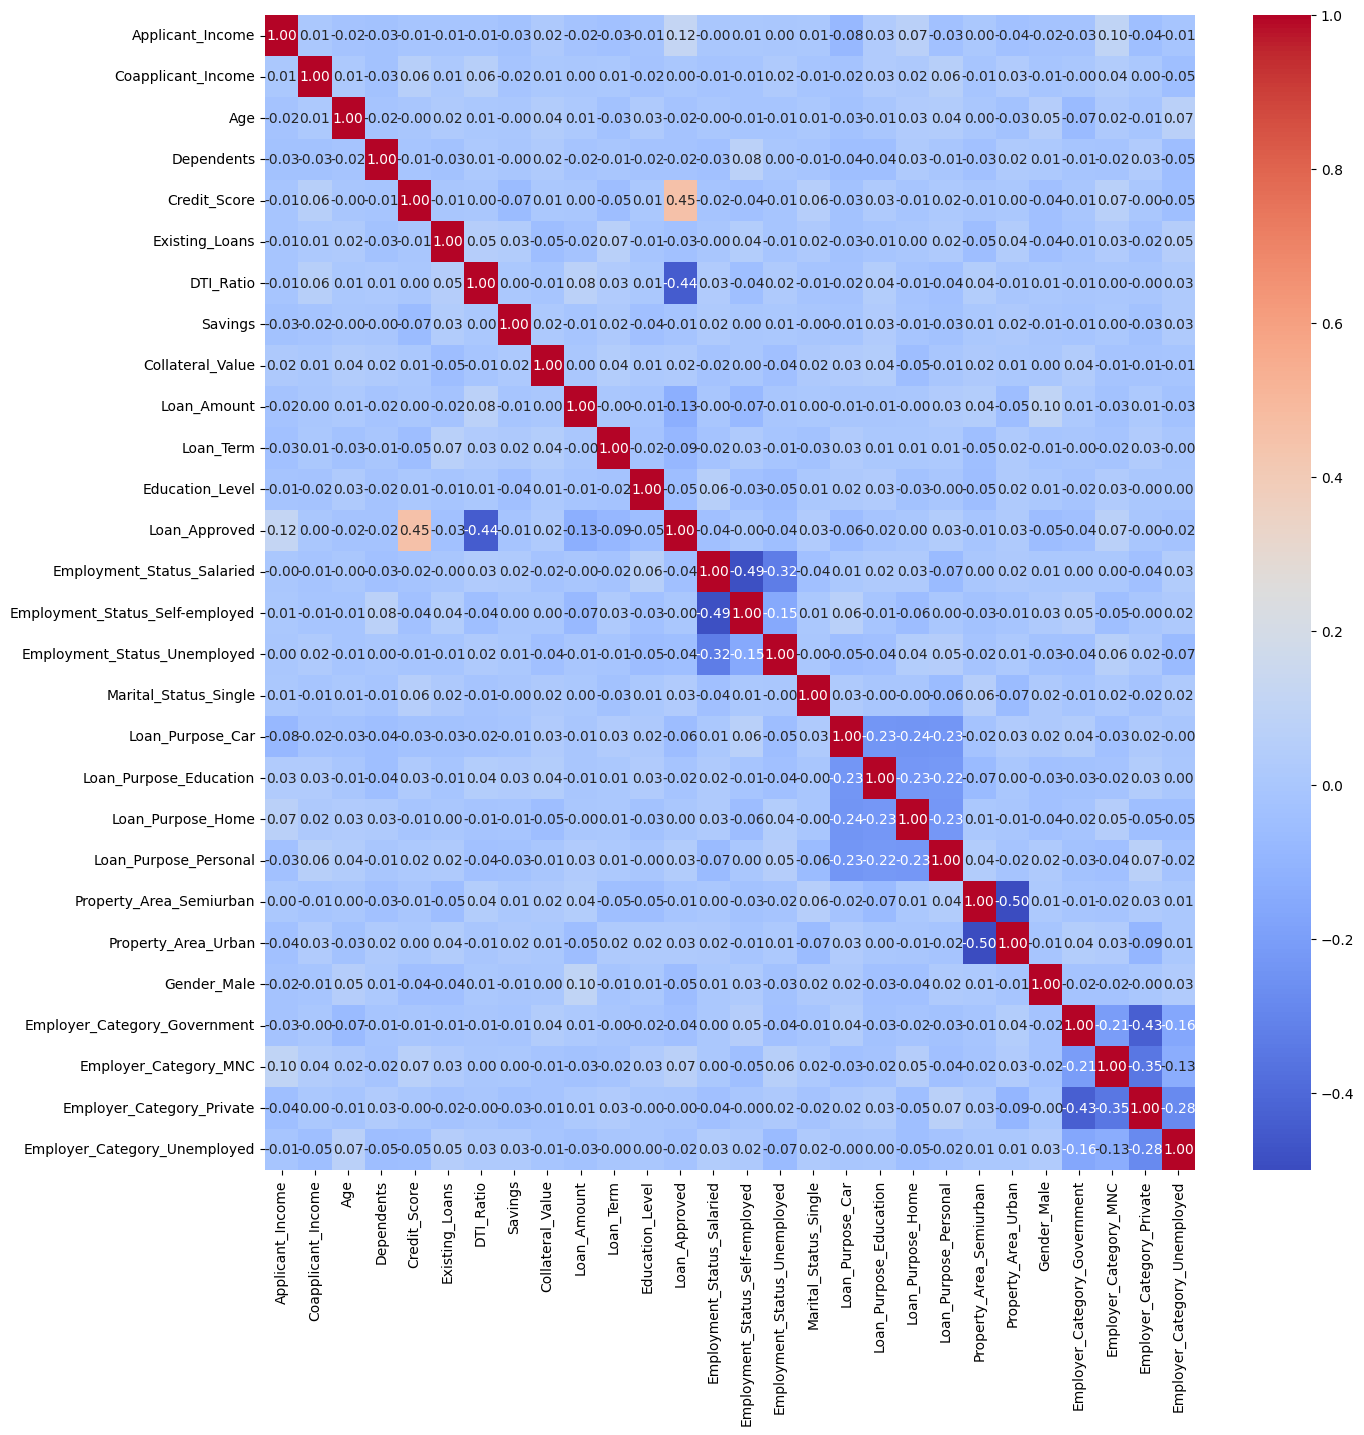

In [36]:
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"    
)


# Train-Test-Split + Feature Scaling

In [39]:
X=loan.drop("Loan_Approved",axis=1)
y=loan["Loan_Approved"]
# X.head()
# y.head() 
#After OneHotEncoding and due to unbalanced classes and since there are a lot of features, knn is not going to work here because all the features plotted on the knn graph will be sparsely distributed


In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Train and Evaluate Models

In [57]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

log_model=LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred=log_model.predict(X_test_scaled)

#Evaluation Metrics

print("Logistic Regression Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))



Logistic Regression Model:
Confusion Matrix: [[126  13]
 [ 14  47]]
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 Score: 0.7768595041322314
Acccuracy: 0.865


In [74]:
#KNN
#After OneHotEncoding and due to unbalanced classes and since there are a lot of features, knn is not going to work here because all the features plotted on the knn graph will be sparsely distributed


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred=knn_model.predict(X_test_scaled)

#Evaluation Metrics

print("KNN Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))



KNN Model:
Confusion Matrix: [[120  19]
 [ 29  32]]
Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1 Score: 0.5714285714285714
Acccuracy: 0.76


In [77]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled, y_train)

y_pred=gnb_model.predict(X_test_scaled)

#Evaluation Metrics

print("Naive Bayes Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))



Naive Bayes Model:
Confusion Matrix: [[128  11]
 [ 16  45]]
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1 Score: 0.7692307692307693
Acccuracy: 0.865


# Hence the best Model on the basis of Precision => Naive Bayes

# Feature Engineering

In [90]:
#Increasing the importance/impact of the features that matter the most(Add or Transform features) 
loan["DTI_Ratio_sq"]=loan["DTI_Ratio"]**2
loan["Credit_Score_sq"]=loan["Credit_Score"]**2

# if reverse, Reducing the importance/impact of the features that don't matter that much(Skewed Data),do this
# loan["Applicant_Income_log"]=np.log1p(loan["Applicant_Income"])


X=loan.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])  #"Applicant_Income"
y=loan["Loan_Approved"] 

#Train-Test-Split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [92]:
#Fine Logistic Regression


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

log_model=LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred=log_model.predict(X_test_scaled)

#Evaluation Metrics

print("Logistic Regression Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))



Logistic Regression Model:
Confusion Matrix: [[125  14]
 [ 10  51]]
Precision: 0.7846153846153846
Recall: 0.8360655737704918
F1 Score: 0.8095238095238095
Acccuracy: 0.88


In [93]:
#Fine Tuned KNN
#After OneHotEncoding and due to unbalanced classes and since there are a lot of features, knn is not going to work here because all the features plotted on the knn graph will be sparsely distributed

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred=knn_model.predict(X_test_scaled)

#Evaluation Metrics

print("KNN Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))


KNN Model:
Confusion Matrix: [[122  17]
 [ 26  35]]
Precision: 0.6730769230769231
Recall: 0.5737704918032787
F1 Score: 0.6194690265486725
Acccuracy: 0.785


In [94]:
#Fine Tuned Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

gnb_model=GaussianNB()
gnb_model.fit(X_train_scaled, y_train)

y_pred=gnb_model.predict(X_test_scaled)

#Evaluation Metrics

print("Naive Bayes Model:")
print("Confusion Matrix:", confusion_matrix(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
print("Acccuracy:", accuracy_score(y_test,y_pred))

Naive Bayes Model:
Confusion Matrix: [[129  10]
 [ 18  43]]
Precision: 0.8113207547169812
Recall: 0.7049180327868853
F1 Score: 0.7543859649122807
Acccuracy: 0.86
